Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
file_path = "../data/raw/Guns incident Data.csv"
df = pd.read_csv(file_path)

# Basic Data Overview

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100798 entries, 0 to 100797
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   S.No.               100798 non-null  int64  
 1   Year                100798 non-null  int64  
 2   Month               100798 non-null  int64  
 3   Date                100798 non-null  object 
 4   Reason              100798 non-null  object 
 5   Education           99376 non-null   object 
 6   Sex                 100798 non-null  object 
 7   Age                 100780 non-null  float64
 8   Race                100798 non-null  object 
 9   Hispanic            100798 non-null  int64  
 10  Place of incident   99414 non-null   object 
 11  Police involvement  100798 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 9.2+ MB


,S.No.,Year,Month,Age,Hispanic,Police involvement
count,100798.000000,100798.000000,100798.000000,100780.000000,100798.000000,100798.000000
mean,50399.500000,2018.000357,6.567601,44.857601,114.179607,0.013909
std,29098.020554,0.816278,3.405609,19.496181,61.595734,0.117114
min,1.000000,2017.000000,1.000000,1.000000,100.000000,0.000000
25%,25200.250000,2017.000000,4.000000,28.000000,100.000000,0.000000
50%,50399.500000,2018.000000,7.000000,43.000000,100.000000,0.000000
75%,75598.750000,2019.000000,9.000000,59.000000,100.000000,0.000000
max,100798.000000,2019.000000,12.000000,108.000000,998.000000,1.000000


There are 100798 rows of data, with 12 columns.

# Univariate Analysis

## (a) Age Distribution

Text(0.5, 1.0, "Distribution of Victims' Age")

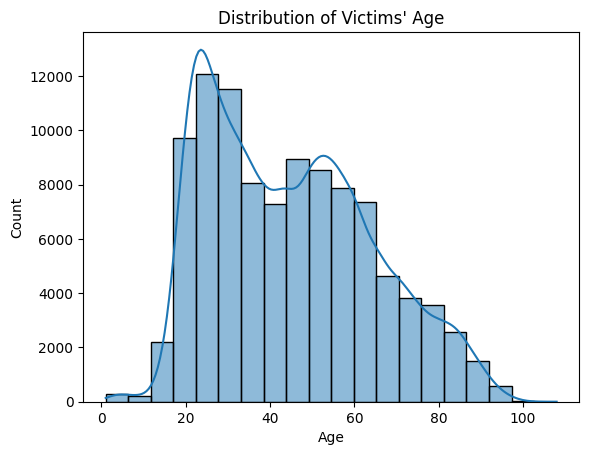

In [10]:
sns.histplot(df['Age'], kde=True, bins=20)
plt.title("Distribution of Victims' Age")

## (b) Sex Distribution

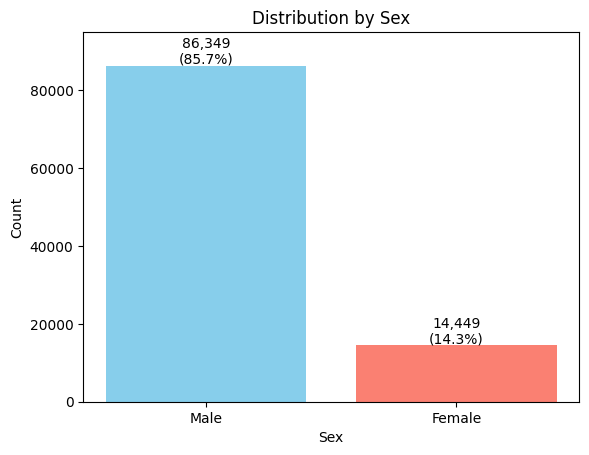

In [71]:
# Calculate counts and percentage
sex_counts = df['Sex'].value_counts()
sex_percent = sex_counts / sex_counts.sum() * 100

plt.bar(sex_counts.index, sex_counts.values, color = ['skyblue', 'salmon'])

# Add percentage and count labels
for i in range(len(sex_counts)):
    plt.text(
        i, sex_counts.iloc[i] + 500,
        f"{sex_counts.iloc[i]:,}\n({sex_percent.iloc[i]:.1f}%)",
        ha='center', fontsize=10
    )

plt.title("Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.ylim(0, sex_counts.max() * 1.1)
plt.show()


## (c) Education Level

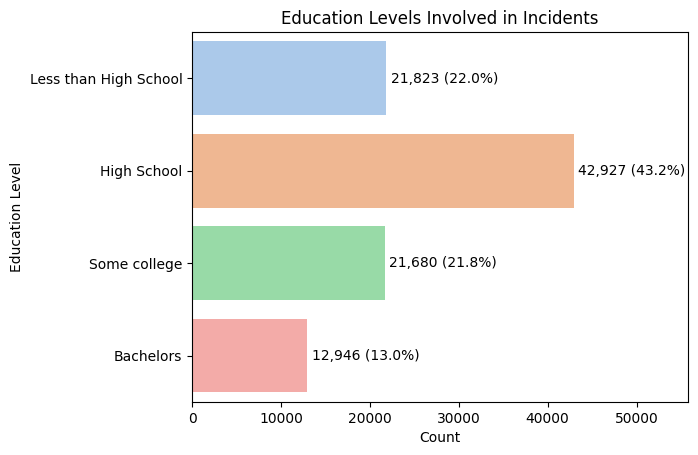

In [68]:
# Order of education
education_level = ['Less than High School', 'High School', 'Some college', 'Bachelors']

# Calculate counts and percentage
education_counts = df['Education'].value_counts()
education_percentage = education_counts / education_counts.sum() * 100

# Reorder to sequence in order of education
education_counts = education_counts.reindex(education_level)
education_percentage = education_percentage.reindex(education_level)

# Bar chart
bars = sns.barplot(
    y=education_counts.index,
    x=education_counts.values,
    hue=education_counts.index,
    palette=sns.color_palette("pastel", len(education_level)),
    legend=False
)

# Add count and percentage labels
for i in range(len(education_level)):
    plt.text(
        education_counts.iloc[i] + 500, i,
        f"{int(education_counts.iloc[i]):,} ({education_percentage.iloc[i]:.1f}%)",
        va='center', fontsize=10
    )

plt.title("Education Levels Involved in Incidents")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.xlim(0, education_counts.max() * 1.3)
plt.show()

## (d) Race

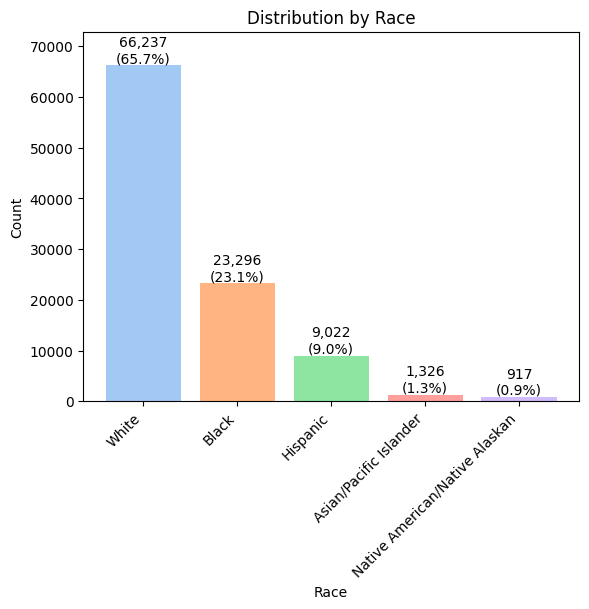

In [67]:
# Calculate counts and percentage
race_counts = df['Race'].value_counts()
race_percent = race_counts / race_counts.sum() * 100

plt.bar(race_counts.index, 
        race_counts.values, 
        color=sns.color_palette("pastel"))

# Add count and percentage labels
for i in range(len(race_counts)):
    plt.text(
        i, race_counts.iloc[i] + 500,
        f"{race_counts.iloc[i]:,}\n({race_percent.iloc[i]:.1f}%)",
        ha='center', fontsize=10
    )

plt.title("Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, race_counts.max() * 1.1)
plt.show()

# Bivariate Relationships

## (a) Age vs Reason

C:\Users\Beckh\AppData\Local\Temp\ipykernel_26016\1407694925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Reason', y = 'Age', data = df, palette = 'pastel')


Text(0.5, 1.0, 'Age Distribution by Reason for Incident')

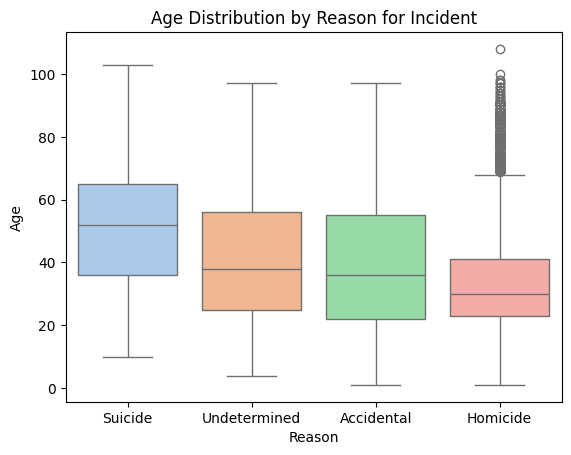

In [66]:
sns.boxplot(x = 'Reason', y = 'Age', data = df, palette = 'pastel')
plt.title("Age Distribution by Reason for Incident")

## (b) Sex vs Reason

Text(0.5, 1.0, 'Incident Reason by Sex')

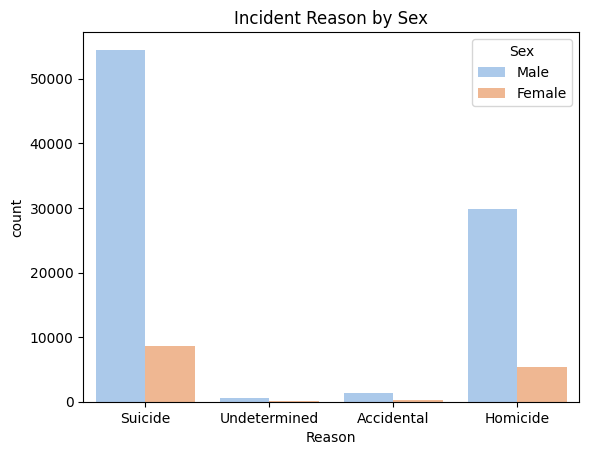

In [74]:
sns.countplot(x='Reason', hue='Sex', data=df, palette = 'pastel')
plt.title("Incident Reason by Sex")

## (c) Race vs Reason

Text(0.5, 1.0, 'Incident Reasons by Race')

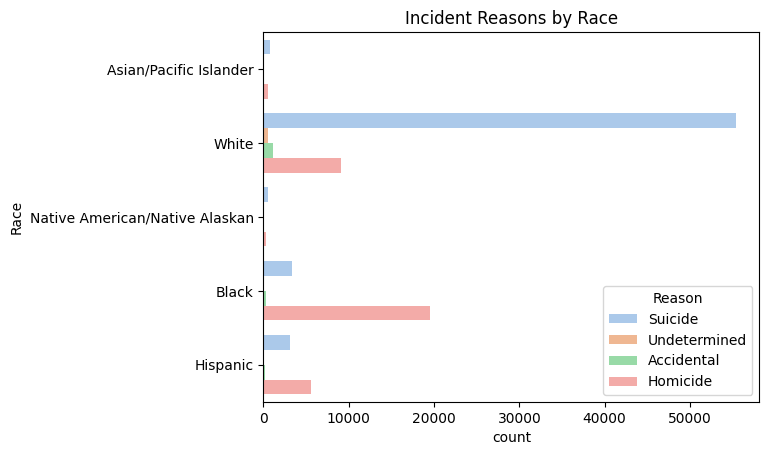

In [76]:
sns.countplot(y='Race', hue='Reason', data=df, palette = 'pastel')
plt.title("Incident Reasons by Race")

## (d) Education vs Reason

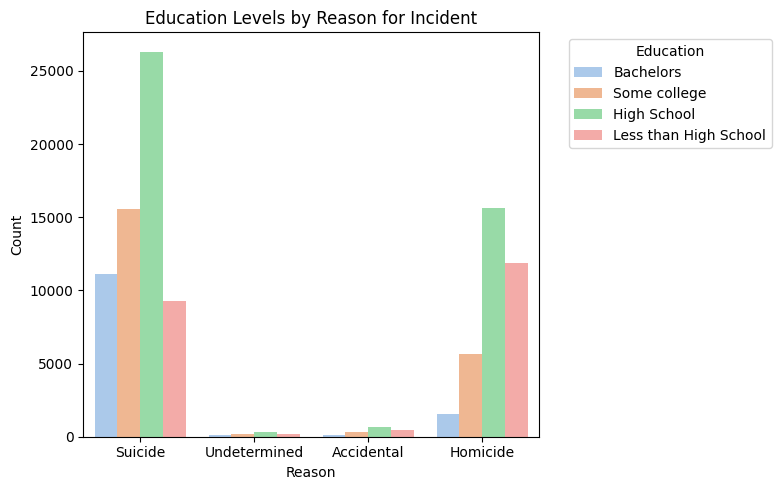

In [78]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Reason',
    hue='Education',
    palette='pastel'
)

plt.title("Education Levels by Reason for Incident")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.legend(title="Education", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


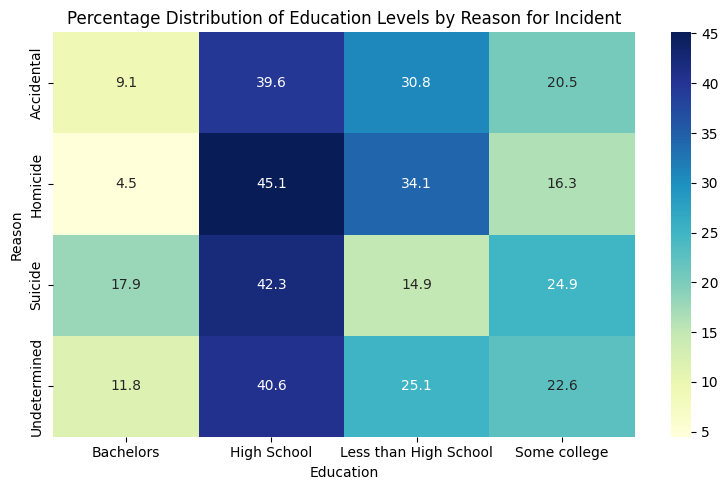

In [79]:
edu_reason = pd.crosstab(df['Reason'], df['Education'], normalize='index') * 100

plt.figure(figsize=(8,5))
sns.heatmap(edu_reason, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Percentage Distribution of Education Levels by Reason for Incident")
plt.xlabel("Education")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

# Temporal patterns

# Place of Incident

# Police Involvement 